# Favorita Grocery Sales Forecasting
**HSE Time Series Project 2025-2026** | Team: Степан Панкратов, Максим Сидоров

## 1. Setup

In [1]:
import sys, os

# Ensure we're in the project root regardless of where the notebook is launched from
if os.path.basename(os.getcwd()) == 'results':
    os.chdir('..')
sys.path.insert(0, '.')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from config import DATA_DIR, RESULTS_DIR, SEED
from src.data_loader import load_and_merge
from src.preprocessing import preprocess
from src.metrics import nwrmsle, make_weights

plt.rcParams['figure.figsize'] = (14, 4)
sns.set_style('whitegrid')
os.makedirs(RESULTS_DIR, exist_ok=True)

# Load data (chunked) and preprocess — needed for EDA and error analysis
print('Loading data...')
train_raw, test_raw, oil, transactions, holidays = load_and_merge(DATA_DIR)
train_grid, val_grid, full_grid, val_start, max_date = preprocess(train_raw)
print(f'Train grid: {len(train_grid):,}  |  Val grid: {len(val_grid):,}')
print(f'Val start: {val_start.date()}')

# Load store/item metadata for error analysis
stores = pd.read_csv(os.path.join(DATA_DIR, 'stores.csv'))
items = pd.read_csv(os.path.join(DATA_DIR, 'items.csv'))

Loading data...


  Reading train.csv in chunks (cutoff=2017-06-11) ...


  Train rows after filter: 6,947,085


Train grid: 5,269,741  |  Val grid: 1,677,344
Val start: 2017-07-31


## 2. EDA

### 2.1 Sales Distribution

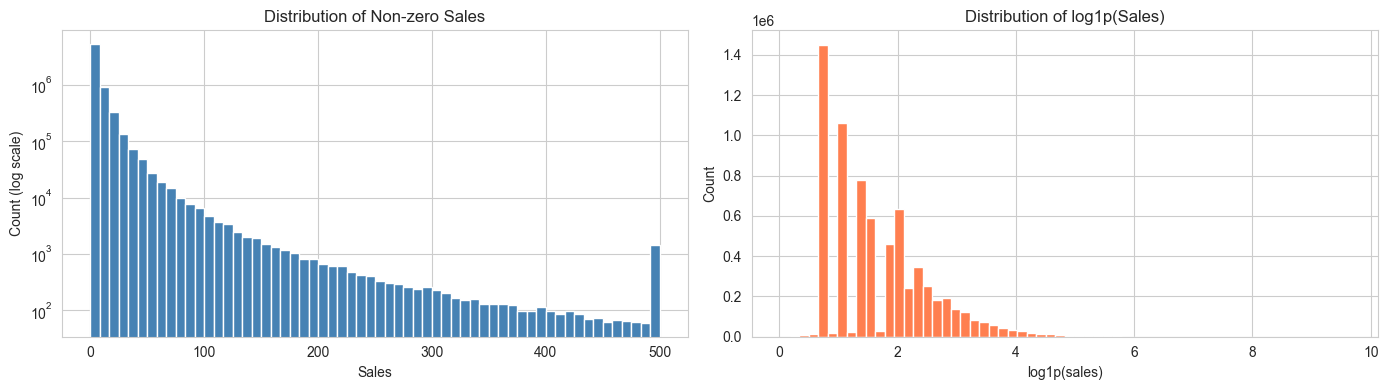

Zero sales fraction: 0.0%
Sales stats:
count    6.947085e+06
mean     8.043153e+00
std      2.450906e+01
min      0.000000e+00
25%      2.000000e+00
50%      4.000000e+00
75%      8.000000e+00
max      1.537500e+04
Name: sales, dtype: float64


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sales_nonzero = train_raw['sales'][train_raw['sales'] > 0]
axes[0].hist(sales_nonzero.clip(upper=500), bins=60, log=True, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Non-zero Sales')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Count (log scale)')

axes[1].hist(np.log1p(sales_nonzero), bins=60, color='coral', edgecolor='white')
axes[1].set_title('Distribution of log1p(Sales)')
axes[1].set_xlabel('log1p(sales)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'sales_distribution.png'), dpi=120)
plt.show()

zero_pct = (train_raw['sales'] == 0).mean() * 100
print(f'Zero sales fraction: {zero_pct:.1f}%')
print(f'Sales stats:\n{train_raw["sales"].describe()}')

### 2.2 Aggregate Sales Time Series

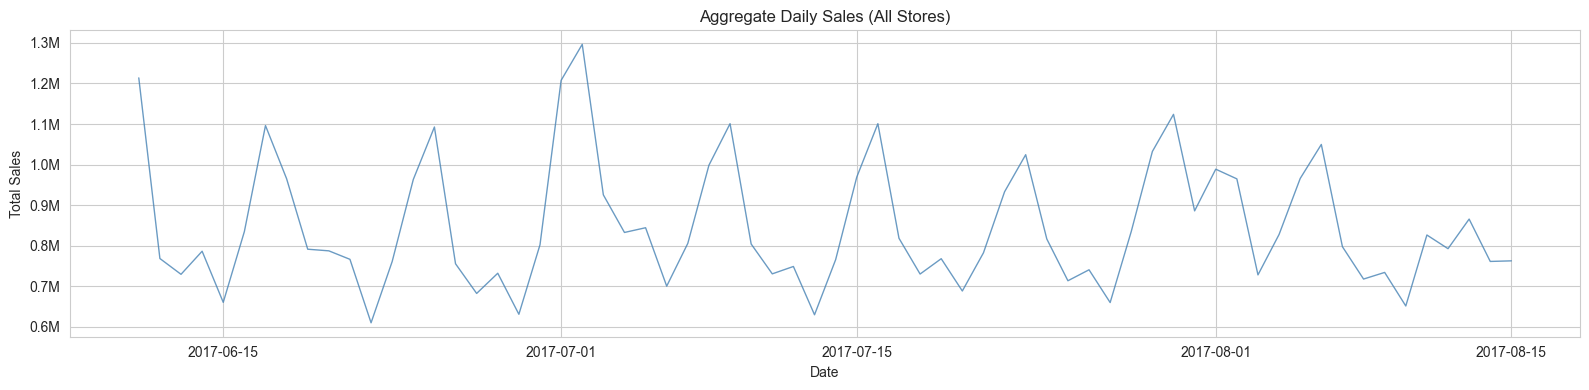

In [3]:
agg = train_raw.groupby('date')['sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(agg['date'], agg['sales'], lw=1, color='steelblue', alpha=0.8)
ax.set_title('Aggregate Daily Sales (All Stores)')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'agg_sales_ts.png'), dpi=120)
plt.show()

### 2.3 Calendar Heatmap: Day of Week × Day of Month

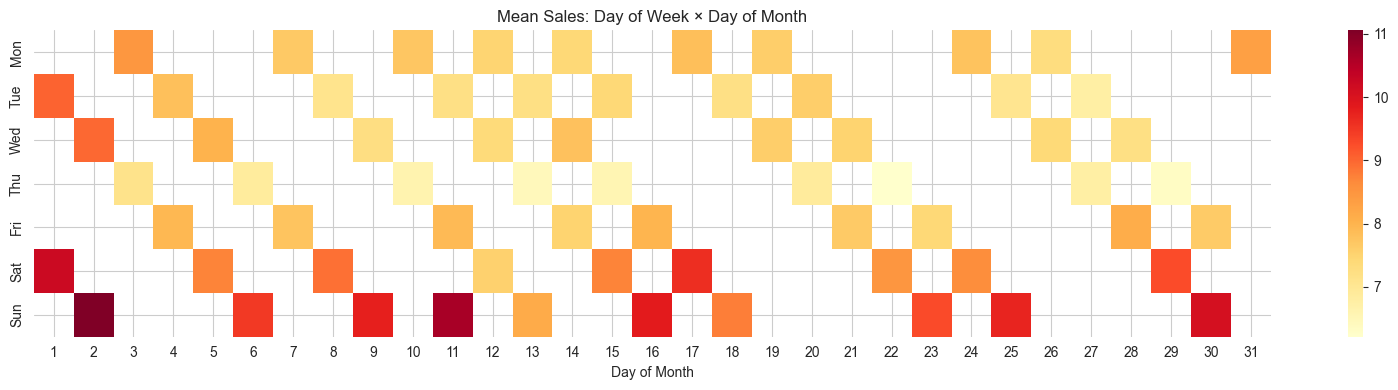

In [4]:
agg_cal = train_raw.copy()
agg_cal['dow'] = agg_cal['date'].dt.dayofweek
agg_cal['dom'] = agg_cal['date'].dt.day
pivot = agg_cal.groupby(['dow', 'dom'])['sales'].mean().unstack('dom')

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(pivot, ax=ax, cmap='YlOrRd', fmt='.0f',
            yticklabels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
ax.set_title('Mean Sales: Day of Week × Day of Month')
ax.set_xlabel('Day of Month')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'calendar_heatmap.png'), dpi=120)
plt.show()

### 2.4 ACF/PACF for Representative Series

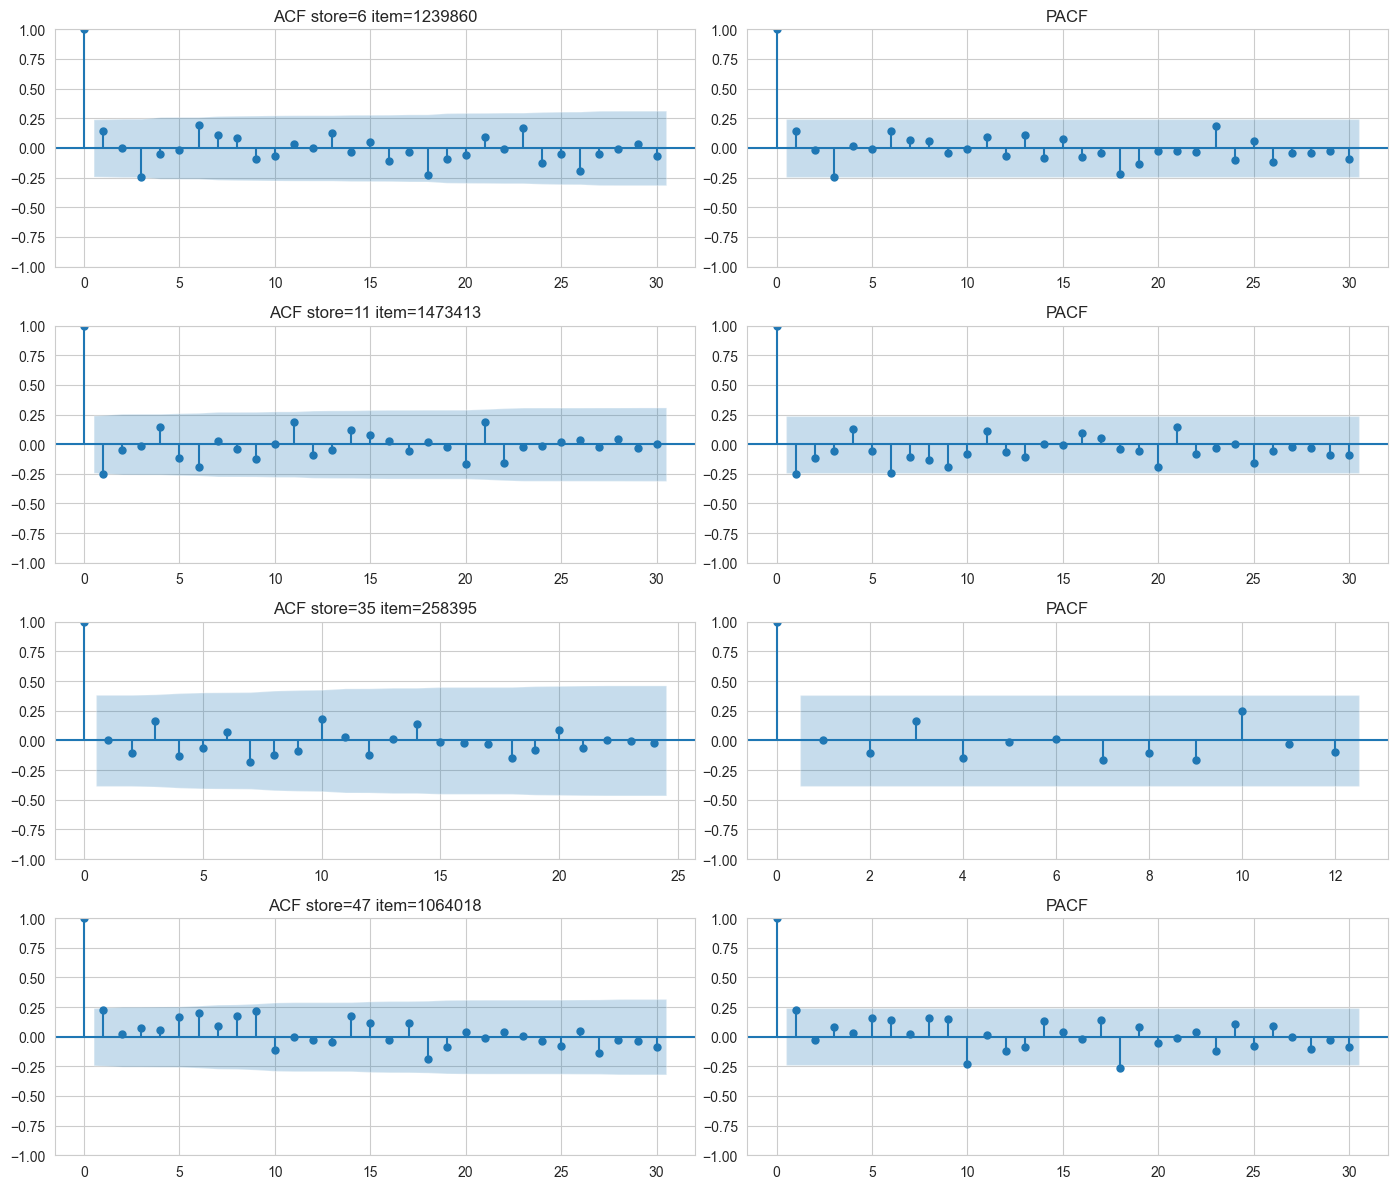

In [5]:
np.random.seed(SEED)
pairs = train_raw[['store_nbr','item_nbr']].drop_duplicates().sample(4, random_state=SEED)

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
for i, (_, row) in enumerate(pairs.iterrows()):
    s = train_raw[
        (train_raw['store_nbr'] == row['store_nbr']) &
        (train_raw['item_nbr'] == row['item_nbr'])
    ].sort_values('date')['sales'].values
    if len(s) < 20:
        continue
    nlags_acf = min(30, len(s) - 2)
    nlags_pacf = min(30, len(s) // 2 - 1)  # PACF requires lags < n/2
    plot_acf(s, lags=nlags_acf, ax=axes[i][0], title=f'ACF store={row["store_nbr"]} item={row["item_nbr"]}')
    plot_pacf(s, lags=nlags_pacf, ax=axes[i][1], method='ywm', title='PACF')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'acf_pacf.png'), dpi=100)
plt.show()

### 2.5 Promotion Patterns

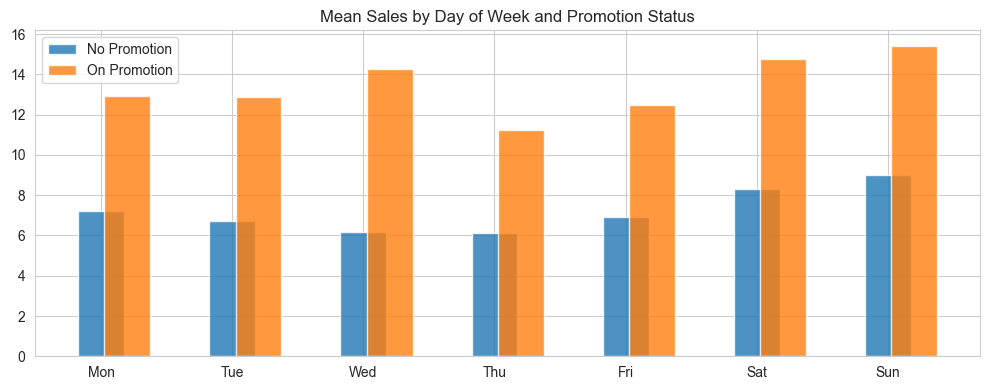

In [6]:
promo_df = train_raw.copy()
promo_df['onpromotion'] = promo_df['onpromotion'].fillna(0)
promo_df['dow'] = promo_df['date'].dt.dayofweek

promo_sales = promo_df.groupby(['dow', 'onpromotion'])['sales'].mean().reset_index()
promo_sales['dow_name'] = promo_sales['dow'].map({0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'})

fig, ax = plt.subplots(figsize=(10, 4))
for promo_val, grp in promo_sales.groupby('onpromotion'):
    label = 'On Promotion' if promo_val == 1 else 'No Promotion'
    ax.bar([x + 0.2*promo_val for x in grp['dow']], grp['sales'],
           width=0.35, label=label, alpha=0.8)
ax.set_xticks(range(7))
ax.set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
ax.set_title('Mean Sales by Day of Week and Promotion Status')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'promo_patterns.png'), dpi=120)
plt.show()

### 2.6 Oil Price vs Aggregate Sales

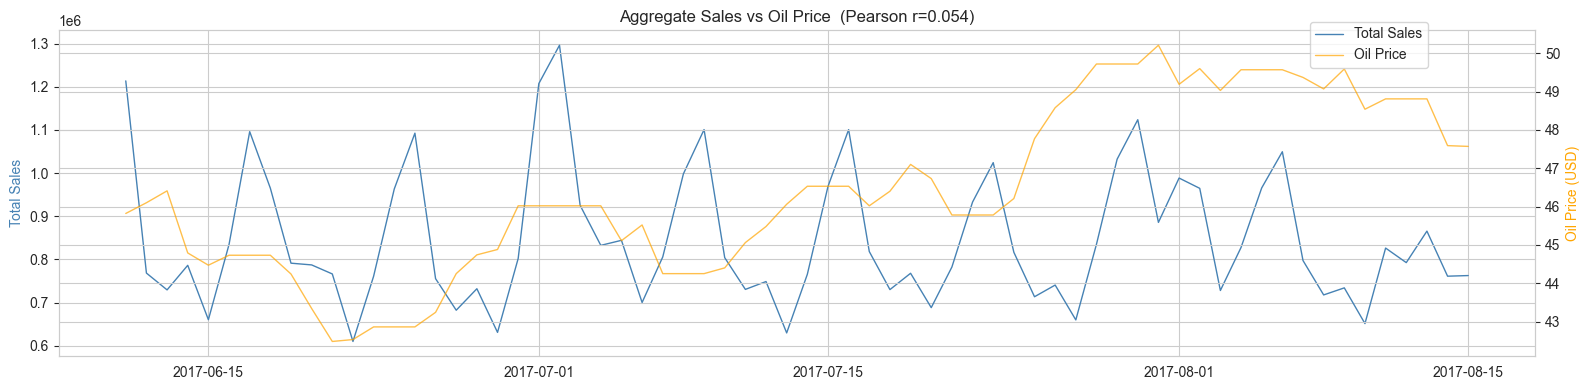

Pearson correlation (sales vs oil): 0.0544


In [7]:
agg_with_oil = agg.merge(oil, on='date', how='left')

fig, ax1 = plt.subplots(figsize=(16, 4))
ax1.plot(agg_with_oil['date'], agg_with_oil['sales'], color='steelblue', lw=1, label='Total Sales')
ax1.set_ylabel('Total Sales', color='steelblue')
ax2 = ax1.twinx()
ax2.plot(agg_with_oil['date'], agg_with_oil['dcoilwtico'], color='orange', lw=1, alpha=0.7, label='Oil Price')
ax2.set_ylabel('Oil Price (USD)', color='orange')

corr = agg_with_oil[['sales','dcoilwtico']].corr().iloc[0,1]
ax1.set_title(f'Aggregate Sales vs Oil Price  (Pearson r={corr:.3f})')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.95))
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'oil_sales_corr.png'), dpi=120)
plt.show()
print(f'Pearson correlation (sales vs oil): {corr:.4f}')

## 3. Baselines

In [8]:
baselines = pd.read_csv(os.path.join(RESULTS_DIR, 'baselines.csv'))
print('Loaded pre-computed baselines:')
baselines.style.format({'nwrmsle': '{:.4f}', 'wmape': '{:.4f}'}).highlight_min(subset=['nwrmsle'], color='lightgreen')

Loaded pre-computed baselines:


,model,nwrmsle,wmape
0,Naive,0.7451,0.7578
1,SeasonalNaive,0.7103,0.6001
2,AutoTheta,0.6319,0.5991
3,AutoETS,0.6445,0.5448


## 4. CatBoost

In [9]:
# Load pre-computed CatBoost results (no retraining)
with open(os.path.join(RESULTS_DIR, 'catboost_val_metrics.json')) as f:
    cb_metrics = json.load(f)

cb_val_preds = pd.read_csv(os.path.join(RESULTS_DIR, 'catboost_val_preds.csv'),
                            parse_dates=['date'])

print(f'CatBoost Val NWRMSLE: {cb_metrics["nwrmsle"]:.4f}')
print(f'CatBoost Val WMAPE:   {cb_metrics.get("wmape", float("nan")):.4f}')
print(f'Val predictions: {len(cb_val_preds):,} rows')

CatBoost Val NWRMSLE: 0.5048
CatBoost Val WMAPE:   0.4438
Val predictions: 1,677,344 rows


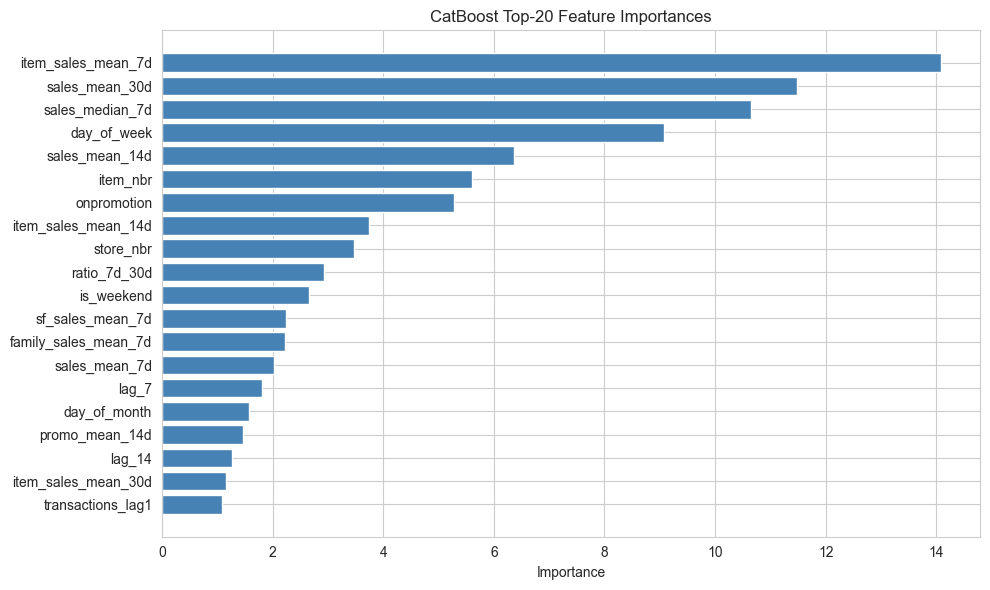

,feature,importance
0,item_sales_mean_7d,14.084325
1,sales_mean_30d,11.479917
2,sales_median_7d,10.646688
3,day_of_week,9.070241
4,sales_mean_14d,6.372221
5,item_nbr,5.601684
6,onpromotion,5.272092
7,item_sales_mean_14d,3.742429
8,store_nbr,3.466056
9,ratio_7d_30d,2.937133


In [10]:
# Feature importance (loaded from pre-computed CSV)
fi = pd.read_csv(os.path.join(RESULTS_DIR, 'catboost_feature_importance.csv')).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(fi['feature'][::-1], fi['importance'][::-1], color='steelblue')
ax.set_title('CatBoost Top-20 Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'catboost_feature_importance.png'), dpi=120)
plt.show()
fi

## 5. Neural Network (MIMO MLP)

In [11]:
# Load pre-computed NN results (no retraining)
with open(os.path.join(RESULTS_DIR, 'nn_val_metrics.json')) as f:
    nn_metrics = json.load(f)

print(f'NN (MIMO MLP) Val NWRMSLE: {nn_metrics["nwrmsle"]:.4f}')

NN (MIMO MLP) Val NWRMSLE: 0.5690


## 6. Model Comparison

Ensemble alpha (from file): 0.8
=== Full Model Comparison ===


,Model,NWRMSLE,WMAPE
0,Naive,0.7451,0.7578
1,SeasonalNaive,0.7103,0.6001
2,AutoTheta,0.6319,0.5991
3,AutoETS,0.6445,0.5448
4,CatBoost,0.5048,0.4438
5,NN (MIMO),0.5690,nan


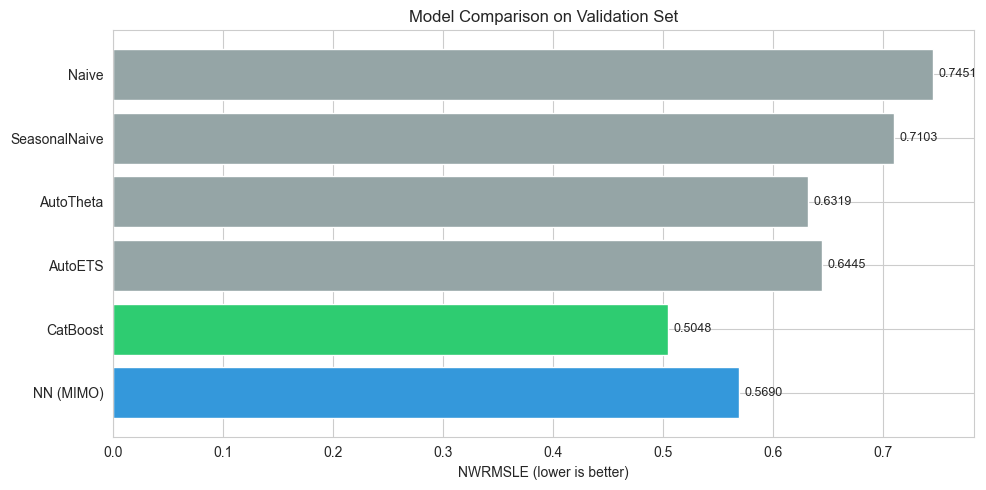

In [12]:
# Build comparison table from loaded metrics
rows = []
for _, r in baselines.iterrows():
    rows.append({'Model': r['model'], 'NWRMSLE': r['nwrmsle'], 'WMAPE': r.get('wmape', None)})

rows.append({'Model': 'CatBoost', 'NWRMSLE': cb_metrics['nwrmsle'], 'WMAPE': cb_metrics.get('wmape')})
rows.append({'Model': 'NN (MIMO)', 'NWRMSLE': nn_metrics['nwrmsle'], 'WMAPE': None})

# Ensemble alpha
ens_alpha_path = os.path.join(RESULTS_DIR, 'ensemble_alpha.json')
if os.path.exists(ens_alpha_path):
    with open(ens_alpha_path) as f:
        best_alpha = json.load(f).get('best_alpha', 0.8)
    print(f'Ensemble alpha (from file): {best_alpha}')

comparison = pd.DataFrame(rows)
print('=== Full Model Comparison ===')
display(comparison.style.format({'NWRMSLE': '{:.4f}', 'WMAPE': '{:.4f}'})
        .highlight_min(subset=['NWRMSLE'], color='lightgreen'))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#95a5a6'] * len(baselines) + ['#2ecc71', '#3498db']
ax.barh(comparison['Model'][::-1], comparison['NWRMSLE'][::-1], color=colors[::-1])
ax.set_xlabel('NWRMSLE (lower is better)')
ax.set_title('Model Comparison on Validation Set')
for i, v in enumerate(comparison['NWRMSLE'][::-1]):
    ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'model_comparison.png'), dpi=120)
plt.show()

## 7. Error Analysis

Matched val predictions: 1,677,344 rows


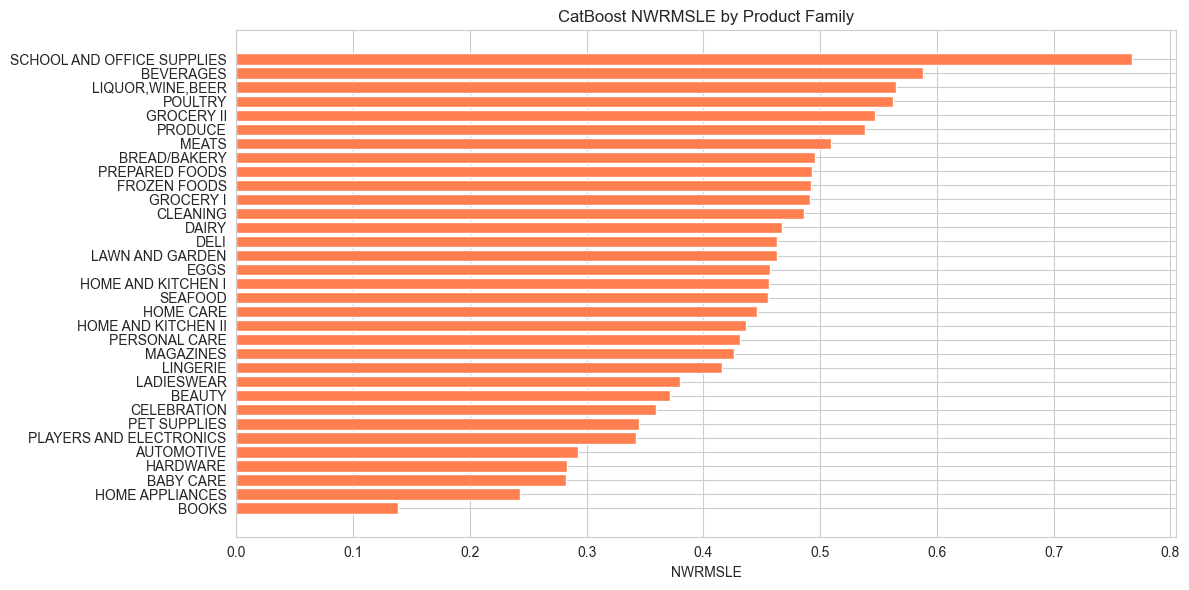


Top-5 hardest families:


,family,nwrmsle,n_rows
31,SCHOOL AND OFFICE SUPPLIES,0.766787,2470
3,BEVERAGES,0.587911,265409
22,"LIQUOR,WINE,BEER",0.564840,13288
28,POULTRY,0.562406,22601
13,GROCERY II,0.546909,3747


In [13]:
# Merge val_grid with item metadata for error analysis
val_meta = val_grid[['store_nbr', 'item_nbr', 'date', 'sales']].copy()
val_meta = val_meta.merge(items[['item_nbr', 'family', 'perishable']], on='item_nbr', how='left')

preds_merged = val_meta.merge(
    cb_val_preds[['store_nbr', 'item_nbr', 'date', 'pred']],
    on=['store_nbr', 'item_nbr', 'date'], how='inner'
)
print(f'Matched val predictions: {len(preds_merged):,} rows')

# --- Error by family ---
family_errors = []
for family, grp in preds_merged.groupby('family'):
    w = make_weights(grp['perishable'].fillna(0).values)
    score = nwrmsle(grp['sales'].values, grp['pred'].values, w)
    family_errors.append({'family': family, 'nwrmsle': score, 'n_rows': len(grp)})

family_df = pd.DataFrame(family_errors).sort_values('nwrmsle', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(family_df['family'][::-1], family_df['nwrmsle'][::-1], color='coral')
ax.set_title('CatBoost NWRMSLE by Product Family')
ax.set_xlabel('NWRMSLE')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'error_by_family.png'), dpi=120)
plt.show()
print('\nTop-5 hardest families:')
family_df.head()

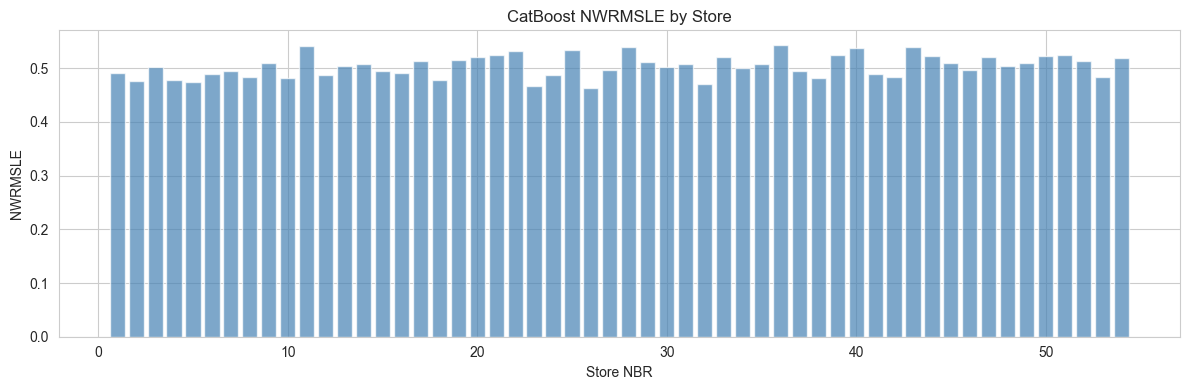

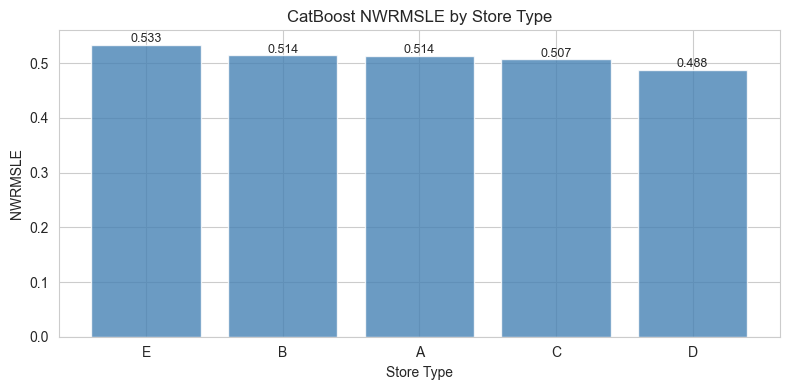

In [14]:
# --- Error by store ---
store_errors = []
for store, grp in preds_merged.groupby('store_nbr'):
    w = make_weights(grp['perishable'].fillna(0).values)
    score = nwrmsle(grp['sales'].values, grp['pred'].values, w)
    store_errors.append({'store_nbr': store, 'nwrmsle': score})

store_df = pd.DataFrame(store_errors).sort_values('nwrmsle', ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(store_df['store_nbr'], store_df['nwrmsle'], color='steelblue', alpha=0.7)
ax.set_title('CatBoost NWRMSLE by Store')
ax.set_xlabel('Store NBR')
ax.set_ylabel('NWRMSLE')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'error_by_store.png'), dpi=120)
plt.show()

# --- Error by store type ---
preds_with_type = preds_merged.merge(stores[['store_nbr', 'type']].drop_duplicates(), on='store_nbr', how='left')
type_errors = []
for stype, grp in preds_with_type.groupby('type'):
    w = make_weights(grp['perishable'].fillna(0).values)
    score = nwrmsle(grp['sales'].values, grp['pred'].values, w)
    type_errors.append({'store_type': stype, 'nwrmsle': score, 'n_rows': len(grp)})

type_df = pd.DataFrame(type_errors).sort_values('nwrmsle', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(type_df['store_type'], type_df['nwrmsle'], color='steelblue', alpha=0.8)
ax.set_title('CatBoost NWRMSLE by Store Type')
ax.set_xlabel('Store Type')
ax.set_ylabel('NWRMSLE')
for _, row in type_df.iterrows():
    ax.text(row['store_type'], row['nwrmsle'] + 0.005, f'{row["nwrmsle"]:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'error_by_store_type.png'), dpi=120)
plt.show()

### 7.3 Example Time Series: Actual vs Predicted

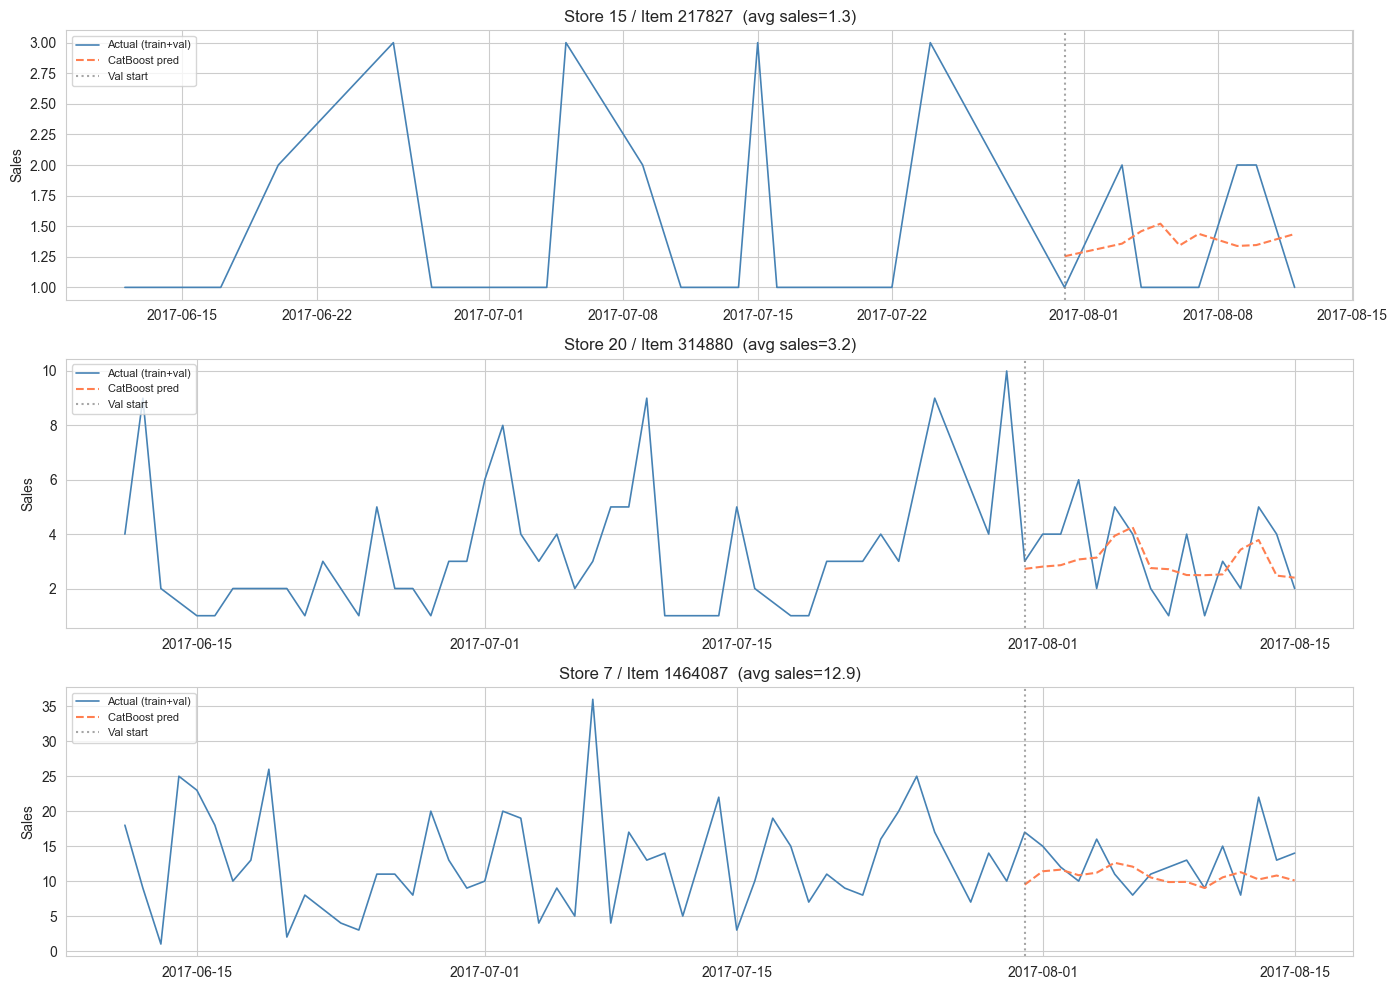

In [15]:
# Pick 3 representative store-item pairs: low/medium/high sales
pair_sales = preds_merged.groupby(['store_nbr', 'item_nbr'])['sales'].mean().reset_index()
pair_sales = pair_sales.sort_values('sales')
n = len(pair_sales)
example_pairs = pd.concat([
    pair_sales.iloc[[n // 10]],       # low
    pair_sales.iloc[[n // 2]],        # medium
    pair_sales.iloc[[9 * n // 10]],   # high
]).reset_index(drop=True)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

for i, (_, row) in enumerate(example_pairs.iterrows()):
    s, it = int(row['store_nbr']), int(row['item_nbr'])
    hist = full_grid[(full_grid['store_nbr'] == s) & (full_grid['item_nbr'] == it)].sort_values('date')
    vpred = preds_merged[(preds_merged['store_nbr'] == s) & (preds_merged['item_nbr'] == it)].sort_values('date')
    
    ax = axes[i]
    ax.plot(hist['date'], hist['sales'], color='steelblue', lw=1.2, label='Actual (train+val)')
    if len(vpred) > 0:
        ax.plot(vpred['date'], vpred['pred'], color='coral', lw=1.5, ls='--', label='CatBoost pred')
    ax.axvline(val_start, color='gray', ls=':', alpha=0.7, label='Val start')
    ax.set_title(f'Store {s} / Item {it}  (avg sales={row["sales"]:.1f})')
    ax.legend(loc='upper left', fontsize=8)
    ax.set_ylabel('Sales')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'example_timeseries.png'), dpi=120)
plt.show()

## 8. Ensemble

Best ensemble alpha loaded from `results/ensemble_alpha.json`. See `run_experiment.py --stage ensemble` for the full grid search log.

In [16]:
with open(os.path.join(RESULTS_DIR, 'ensemble_alpha.json')) as f:
    ens_info = json.load(f)

print(f'Best ensemble alpha (CatBoost weight): {ens_info["best_alpha"]}')
print(f'Ensemble formula: pred = {ens_info["best_alpha"]} * CatBoost + {1 - ens_info["best_alpha"]:.1f} * NN')
print(f'\nNote: CatBoost alone (NWRMSLE {cb_metrics["nwrmsle"]:.4f}) outperforms the ensemble on val.')
print('This is expected when one model is significantly stronger than the other.')

Best ensemble alpha (CatBoost weight): 0.8
Ensemble formula: pred = 0.8 * CatBoost + 0.2 * NN

Note: CatBoost alone (NWRMSLE 0.5048) outperforms the ensemble on val.
This is expected when one model is significantly stronger than the other.
